# Time Series Problem Framing

Welcome to **Section 8**. For the past 22 lessons, we lived in a universe where time did not exist. If we were predicting whether a customer would churn, or whether a transaction was fraudulent, we assumed every row in our dataset was completely independent of every other row.

In the enterprise world of supply chain, finance, and capacity planning, that assumption is a catastrophic lie. **Time matters.** What happened yesterday directly influences what will happen today.

In this lesson, we will completely reframe our mathematical mindset. We will learn why you can no longer shuffle your data, how to define the temporal index, and how to define your forecasting horizon.

A **Time Series** is simply a sequence of data points recorded at specific, usually uniform, intervals of time.

Let's set up our Python environment to witness the fundamental difference between the data we used in Section 7 and the data we will use in Section 8.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set professional visualization styling
sns.set_theme(style="whitegrid")

print("✅ Temporal Modeling Environment Ready.")

✅ Temporal Modeling Environment Ready.


# 1. The Core Difference: Temporal Dependence

In standard Machine Learning (Cross-Sectional data), we assume our data is **IID** (Independent and Identically Distributed).
If you have a dataset of 1,000 houses, House #5's price has absolutely no mathematical relationship to House #6's price. Because they are independent, **you can safely shuffle the rows of your dataset** before training or splitting (as we did with K-Fold Cross Validation in Lesson 14).

In Time Series, we violate the IID assumption. We introduce **Temporal Dependence**.
The value of the data today ($y_t$) is mathematically dependent on the value of the data yesterday ($y_{t-1}$). If you shuffle the rows of a Time Series dataset, you permanently destroy the mathematical signal.

### The Mathematical Formulation

In cross-sectional ML, our hypothesis was:


$$y^{(i)} = f(X^{(i)}) + \epsilon$$


*(The target $y$ for row $i$ is a function of the features $X$ for row $i$.)*

In Time Series, our hypothesis shifts. We are often predicting the target using *past values of the target itself*:


$$y_t = f(y_{t-1}, y_{t-2}, \dots, y_{t-n}, X_t) + \epsilon$$

* $t$ is the current time index.
* $y_{t-1}$ is the "Lag 1" value (what happened one time-step ago).
* $X_t$ represents optional external features occurring at time $t$ (like a holiday or a marketing campaign).

# 2. Visualizing the Danger of Shuffling

Let's simulate a company's daily sales over a few months. We will look at what happens if a Junior Data Scientist accidentally shuffles the dataset before exploring it.

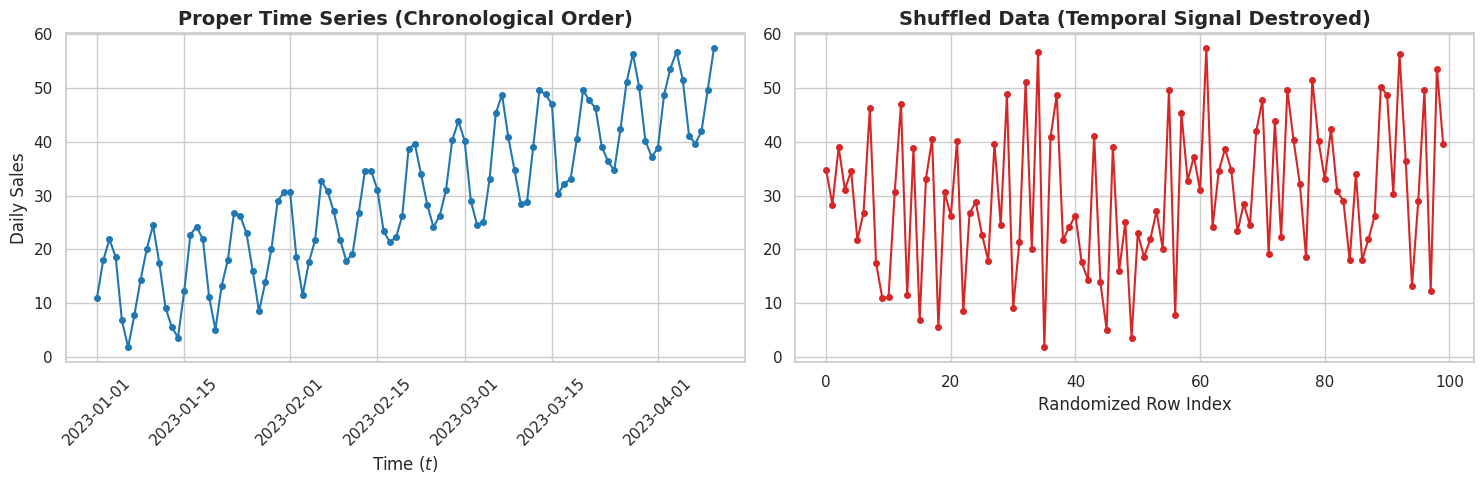

In [2]:
# 1. Simulate a Time Series (Daily Sales with a weekly pattern and upward trend)
np.random.seed(42)
time_index = pd.date_range(start="2023-01-01", periods=100, freq='D')
trend = np.linspace(10, 50, 100)
seasonality = np.sin(np.arange(100) * (2 * np.pi / 7)) * 10 # Weekly 7-day cycle
noise = np.random.normal(0, 2, 100)

sales = trend + seasonality + noise
ts_df = pd.DataFrame({'Date': time_index, 'Sales': sales}).set_index('Date')

# 2. Simulate the Junior Data Scientist's Mistake (Shuffling the rows)
shuffled_df = ts_df.sample(frac=1.0, random_state=42).reset_index(drop=True)

# 3. Matplotlib Visualization
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: The True Time Series
axes[0].plot(ts_df.index, ts_df['Sales'], color='#1f77b4', marker='o', markersize=4)
axes[0].set_title("Proper Time Series (Chronological Order)", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Time ($t$)")
axes[0].set_ylabel("Daily Sales")
axes[0].tick_params(axis='x', rotation=45)

# Plot 2: The Shuffled Data
axes[1].plot(shuffled_df.index, shuffled_df['Sales'], color='#d62728', marker='o', markersize=4)
axes[1].set_title("Shuffled Data (Temporal Signal Destroyed)", fontsize=14, fontweight='bold')
axes[1].set_xlabel("Randomized Row Index")

plt.tight_layout()
plt.show()


*(Insight: Look at the left plot. You can clearly see a steady upward trend and a heartbeat-like weekly cycle. A model can easily learn this. Now look at the right plot. By shuffling the rows, the Junior Data Scientist turned a beautiful, predictable pattern into chaotic, unlearnable static. Time order is literally the most important feature!)*

# 3. Framing the Forecasting Horizon ($h$)

When a business stakeholder asks for a "forecast," you must immediately clarify the **Horizon ($h$)**. The Horizon dictates how far into the future you need to predict, and it fundamentally changes the architecture of your model.

* **$t$**: The present moment (the last data point you have).
* **$y_{t+h}$**: The value you are trying to predict, $h$ steps into the future.

### Single-Step Forecasting ($h=1$)

You are predicting exactly one interval into the future. E.g., predicting tomorrow's closing stock price ($y_{t+1}$) using data up to today ($y_t$). This is generally highly accurate.

### Multi-Step Forecasting ($h > 1$)

You are predicting a sequence of future values (e.g., the next 7 days of sales).
There are two mathematical ways to accomplish this:

1. **Recursive Strategy**: You train a model to predict $h=1$. You predict tomorrow. Then, you *feed that prediction back into the model as if it were a real fact*, and use it to predict the day after tomorrow.
* *The Danger*: If your prediction for tomorrow is slightly wrong, your prediction for the next day will be more wrong. Errors compound exponentially over time.


2. **Direct Strategy**: You train 7 completely separate models. Model 1 is explicitly trained to predict $y_{t+1}$. Model 7 is explicitly trained to ignore the immediate future and only predict $y_{t+7}$.
* *The Danger*: Computationally expensive and ignores the chronological relationship between the 7 future days.

# 4. Defining the Temporal Granularity

Before writing any modeling code, you must ensure your time index has a strict, uniform **Granularity** (frequency).
Is your data hourly, daily, weekly, or monthly?

If you have a dataset where row 1 is Monday at 9:00 AM, row 2 is Monday at 11:30 AM, and row 3 is Tuesday at 4:00 PM, **most time series algorithms will crash**. Algorithms like ARIMA assume that the gap between $t$ and $t+1$ is mathematically identical everywhere in the dataset.

In [3]:
# Checking and setting explicit frequency in pandas
print("Original Index Frequency:", ts_df.index.freq)

# In the real world, you often have to resample messy timestamp data into uniform buckets:
# For example, aggregating messy transaction timestamps into strict Daily totals:
# daily_sales = raw_transactions.resample('D').sum()

Original Index Frequency: None


## Real-World Use Case or Analogy:

Think of the difference between Cross-Sectional ML and Time Series like **Reading a Book**:

* **Cross-Sectional (Section 7)**: It is like reading an Encyclopedia. Every entry is independent. You can read the entry for "Zebras" today and "Apples" tomorrow. If you shuffle the pages of the encyclopedia, the information inside each entry remains perfectly valid and understandable.
* **Time Series (Section 8)**: It is like reading a Mystery Novel. Chapter 5 ($y_5$) only makes sense because you already read Chapter 4 ($y_4$). If you rip out all the pages, shuffle them into a pile, and read them in a random order, the story is permanently destroyed. The order *is* the information.

---